# Beer Data Analysis

## Assignment

In this assignment you will work with a beer data set. Please provide an answer to the questions below. Answer as many questions as possible:

1. Rank the top 3 breweries which produce the strongest beers.
2. Which year did beers enjoy the highest ratings?
3. Based on the users' ratings, which factors are important among taste, aroma, appearance, and palette?
4. If you were to recommend 3 beers to your friends based on this data, which ones would you recommend?
5. Which beer style seems to be the favourite based on the reviews written by users? How does written reviews compare to overall review score for the beer style?

In [36]:
import numpy as np
import pandas as pd

In [37]:
data = pd.read_csv('/Users/rosiebai/Downloads/datasets-6/BeerDataScienceProject.tar.bz2', compression="bz2")

In [38]:
data.head(20)

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time
0,5.0,47986,10325,Sausa Weizen,Hefeweizen,2.5,2.0,1.5,1.5,stcules,1.5,A lot of foam. But a lot. In the smell some ba...,1234817823
1,6.2,48213,10325,Red Moon,English Strong Ale,3.0,2.5,3.0,3.0,stcules,3.0,"Dark red color, light beige foam, average. In ...",1235915097
2,6.5,48215,10325,Black Horse Black Beer,Foreign / Export Stout,3.0,2.5,3.0,3.0,stcules,3.0,"Almost totally black. Beige foam, quite compac...",1235916604
3,5.0,47969,10325,Sausa Pils,German Pilsener,3.5,3.0,3.0,2.5,stcules,3.0,"Golden yellow color. White, compact foam, quit...",1234725145
4,7.7,64883,1075,Cauldron DIPA,American Double / Imperial IPA,4.0,4.5,4.0,4.0,johnmichaelsen,4.5,"According to the website, the style for the Ca...",1293735206
5,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.0,3.0,oline73,3.5,Poured from the bottle into a Chimay goblet. A...,1325524659
6,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.5,4.0,Reidrover,4.0,"22 oz bottle from ""Lifesource"" Salem. $3.95 Ni...",1318991115
7,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,2.5,3.0,2.0,alpinebryant,3.5,"Bottle says ""Malt beverage brewed with Ginger ...",1306276018
8,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.0,4.0,3.5,LordAdmNelson,4.0,I'm not sure why I picked this up... I like gi...,1290454503
9,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,5.0,3.5,4.5,4.0,augustgarage,4.0,Poured from a 22oz bomber into my Drie Fontein...,1285632924


In [39]:
data.dtypes

beer_ABV              float64
beer_beerId             int64
beer_brewerId           int64
beer_name              object
beer_style             object
review_appearance     float64
review_palette        float64
review_overall        float64
review_taste          float64
review_profileName     object
review_aroma          float64
review_text            object
review_time             int64
dtype: object

In [40]:
data.isna().sum()

beer_ABV              20280
beer_beerId               0
beer_brewerId             0
beer_name                 0
beer_style                0
review_appearance         0
review_palette            0
review_overall            0
review_taste              0
review_profileName      115
review_aroma              0
review_text             119
review_time               0
dtype: int64

In [41]:
data.shape

(528870, 13)

In [42]:
data['beer_name'].nunique()

18339

In [43]:
data['beer_name'].value_counts()

beer_name
Sierra Nevada Celebration Ale                 3000
Sierra Nevada Pale Ale                        2587
Founders Breakfast Stout                      2502
Sierra Nevada Bigfoot Barleywine Style Ale    2492
La Fin Du Monde                               2483
                                              ... 
Ur-Saalfelder                                    1
Maribo Slots Pilsner 3,5%                        1
Zwiesel Löwentrunk                               1
Maribo Danish Gold                               1
Sausa Weizen                                     1
Name: count, Length: 18339, dtype: int64

In [44]:
data[data['beer_name']== 'Caldera Ginger Beer'].head()

,beer_ABV,beer_beerId,beer_brewerId,beer_name,beer_style,review_appearance,review_palette,review_overall,review_taste,review_profileName,review_aroma,review_text,review_time
5,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.0,3.0,oline73,3.5,Poured from the bottle into a Chimay goblet. A...,1325524659
6,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.5,3.5,4.0,Reidrover,4.0,"22 oz bottle from ""Lifesource"" Salem. $3.95 Ni...",1318991115
7,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,2.5,3.0,2.0,alpinebryant,3.5,"Bottle says ""Malt beverage brewed with Ginger ...",1306276018
8,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,3.5,3.0,4.0,3.5,LordAdmNelson,4.0,I'm not sure why I picked this up... I like gi...,1290454503
9,4.7,52159,1075,Caldera Ginger Beer,Herbed / Spiced Beer,5.0,3.5,4.5,4.0,augustgarage,4.0,Poured from a 22oz bomber into my Drie Fontein...,1285632924


## 1. Rank the top 3 breweries which produce the strongest beers.


In [62]:
avg_taste_by_brewer_beer = data[data['beer_ABV'].notna()].groupby(['beer_brewerId','beer_name'])['beer_ABV'].mean()\
    .reset_index()
avg_taste_by_brewer = avg_taste_by_brewer_beer.groupby('beer_brewerId').agg(
    avg_beer_abv = ('beer_ABV','mean'),
    max_beer_abv = ('beer_ABV','max'),
    unique_beers = ('beer_name','nunique')).reset_index()\
    .sort_values(by = 'avg_beer_abv', ascending = False)

top3_breweries = avg_taste_by_brewer[avg_taste_by_brewer['unique_beers']>=5].sort_values(by = 'avg_beer_abv', ascending=False).head(3)
top3_breweries
 

,beer_brewerId,avg_beer_abv,max_beer_abv,unique_beers
699,6513,24.690000,57.7,10
73,396,10.165769,12.0,52
1383,22202,9.675000,15.0,10


In [63]:
avg_taste_by_brewer['unique_beers'].describe()

count    1607.000000
mean        9.327940
std        16.041939
min         1.000000
25%         2.000000
50%         5.000000
75%        10.000000
max       243.000000
Name: unique_beers, dtype: float64

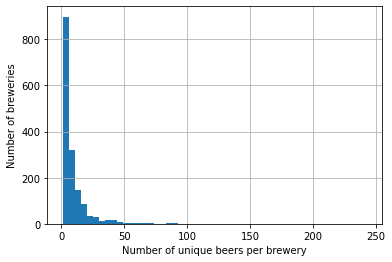

In [64]:
import matplotlib.pyplot as plt

avg_taste_by_brewer["unique_beers"].hist(bins=50)
plt.xlabel("Number of unique beers per brewery")
plt.ylabel("Number of breweries")
plt.show()

In [65]:

avg_taste_by_brewer['rank'] = avg_taste_by_brewer[avg_taste_by_brewer['unique_beers'] >= 5]['avg_beer_abv'].rank(method = 'dense',ascending = False)
top3_breweries = avg_taste_by_brewer[avg_taste_by_brewer['rank'] <= 3]
top3_breweries

,beer_brewerId,avg_beer_abv,max_beer_abv,unique_beers,rank
699,6513,24.690000,57.7,10,1.0
73,396,10.165769,12.0,52,2.0
1383,22202,9.675000,15.0,10,3.0


## 2. Which year did beers enjoy the highest ratings?


In [47]:
data['review_time'] = pd.to_datetime(data['review_time'], unit='s', errors='coerce')
data['review_year'] = data['review_time'].dt.year

In [72]:
review_rating_per_year = data.groupby('review_year').agg(
    avg_rating = ('review_overall','mean'),
    review_count = ('review_overall','count'))\
    .reset_index().sort_values(by = 'avg_rating', ascending = False)
review_rating_per_year[review_rating_per_year['review_count']>= 1000].sort_values(by = 'avg_rating',ascending= False)

,review_year,avg_rating,review_count
12,2010,3.866139,93810
11,2009,3.864390,83578
10,2008,3.833939,69080
7,2005,3.832042,29433
14,2012,3.829717,3180
13,2011,3.828093,110836
9,2007,3.809552,46514
4,2002,3.798905,7581
8,2006,3.798192,43083
6,2004,3.794630,22905


2010 seems to have the highest beer rating.

## 3. Based on the users' ratings, which factors are important among taste, aroma, appearance, and palette?


In [50]:
data.columns

Index(['beer_ABV', 'beer_beerId', 'beer_brewerId', 'beer_name', 'beer_style',
       'review_appearance', 'review_palette', 'review_overall', 'review_taste',
       'review_profileName', 'review_aroma', 'review_text', 'review_time',
       'review_year'],
      dtype='object')

In [51]:
data.isna().sum()

beer_ABV              20280
beer_beerId               0
beer_brewerId             0
beer_name                 0
beer_style                0
review_appearance         0
review_palette            0
review_overall            0
review_taste              0
review_profileName      115
review_aroma              0
review_text             119
review_time               0
review_year               0
dtype: int64

In [52]:
import statsmodels.api as sm
import pandas as pd

# features
X = data[['review_appearance', 'review_palette', 'review_taste', 'review_aroma']]
y = data['review_overall']

# add intercept (VERY important)
X = sm.add_constant(X)

# fit model
model = sm.OLS(y, X).fit()

# full summary
print(model.summary())
results = pd.DataFrame({
    'feature': model.params.index,
    'coefficient': model.params.values,
    'p_value': model.pvalues.values,
    't_stat': model.tvalues.values
})

print(results)

                            OLS Regression Results                            
Dep. Variable:         review_overall   R-squared:                       0.648
Model:                            OLS   Adj. R-squared:                  0.648
Method:                 Least Squares   F-statistic:                 2.430e+05
Date:                Mon, 18 May 2026   Prob (F-statistic):               0.00
Time:                        13:02:48   Log-Likelihood:            -2.9348e+05
No. Observations:              528870   AIC:                         5.870e+05
Df Residuals:                  528865   BIC:                         5.870e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.4483      0.00

Beer aroma turned out to be the most important factor, then it's the taste. And it makes sense, usually before we drink something, we smell it first, and if it smells very good, it might increase our satisfaction with the beer. 

## 4. If you were to recommend 3 beers to your friends based on this data, which ones would you recommend?


In [53]:
data.review_text.isna().sum()/len(data)

0.00022500803600128576

In [54]:
data2 = data.dropna(subset = ['beer_style', 'review_text', 'review_overall'])

In [75]:
import re
import nltk 
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
custom_stopwords = {'beer','like','taste','drink','flavor'}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()
def clean_text2(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]','', text)
    tokens = word_tokenize(text)
    return ' '.join(
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words
    )
data2['clean_review'] = data2['review_text'].apply(clean_text2)

[nltk_data] Downloading package punkt to /Users/rosiebai/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/rosiebai/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/rosiebai/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/cc/102y89n15yjc99kqfmtqxrv00000gn/T/ipykernel_51870/2228663861.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['clean_review'] = data2['review_text'].apply(clean_text2)


In [76]:
# sentiment analysis on text 
from nltk.sentiment import SentimentIntensityAnalyzer 
import nltk 
nltk.download('vader_lexicon')

sia = SentimentIntensityAnalyzer() 
data2['sentiment_score'] = data2['clean_review'].apply(lambda x: sia.polarity_scores(x)['compound'])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/rosiebai/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
/var/folders/cc/102y89n15yjc99kqfmtqxrv00000gn/T/ipykernel_51870/110723314.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data2['sentiment_score'] = data2['clean_review'].apply(lambda x: sia.polarity_scores(x)['compound'])


In [93]:
avg_rating_aroma_taste = (
    data2.groupby(['beer_name', 'beer_style'])
    .agg({
        'review_overall': 'mean',
        'review_aroma': 'mean',
        'review_taste': 'mean',
        'review_palette': 'mean',
        'review_appearance': 'mean',
        'sentiment_score': 'mean',
        'review_text': 'count'   # count of reviews
    })
    .rename(columns={'review_text': 'review_count'})  # optional but clearer
    .reset_index()
    )

In [96]:
avg_rating_aroma_taste = avg_rating_aroma_taste[avg_rating_aroma_taste['review_count']>= 100]
avg_rating_aroma_taste['rank'] = avg_rating_aroma_taste['review_overall'].rank(method = 'dense', ascending=False)
avg_rating_aroma_taste.sort_values(by = 'rank', ascending= True).head(5)

,beer_name,beer_style,review_overall,review_aroma,review_taste,review_palette,review_appearance,sentiment_score,review_count,rank
4192,Citra DIPA,American Double / Imperial IPA,4.630952,4.573413,4.373016,4.690476,4.369048,0.929742,252,1.0
3594,Cantillon Blåbær Lambik,Lambic - Fruit,4.628205,4.628205,4.493590,4.528846,4.644231,0.936012,156,2.0
7665,Heady Topper,American Double / Imperial IPA,4.625800,4.608742,4.405117,4.660981,4.163113,0.873639,469,3.0
6292,Founders CBS Imperial Stout,American Double / Imperial Stout,4.591052,4.697017,4.579278,4.558085,4.457614,0.933985,637,4.0
10633,Masala Mama India Pale Ale,American IPA,4.488671,4.397281,4.332326,4.368580,4.407100,0.893548,662,5.0


If I were to recommend to my friends, I would pick the beer with the highest overall rating with a good amount of reviews, good aroma, good taste and decent appearance and palete. Hence, my recommendations are Citra DIPA, Cantillon Blåbær Lambik, Heady Topper.

## 5. Which beer style seems to be the favourite based on the reviews written by users? How does written reviews compare to overall review score for the beer style?

In [103]:
# aggregate the sentiment scores by beer style
agg_df = data2.groupby('beer_style').agg({
    'review_overall':'mean',
    'sentiment_score':'mean',
    'review_text':'count'
}).rename(columns = {
    'review_overall':'avg_rating',
    'sentiment_score':'avg_sentiment',
    'review_text':'review_count'
})

most_fav_by_rating = agg_df.sort_values(by =['avg_rating','review_count','avg_sentiment',],ascending=False).head(5)
most_fav_by_rating

,avg_rating,avg_sentiment,review_count
beer_style,,,
Gueuze,4.140952,0.808463,1575
Berliner Weissbier,4.133976,0.837339,933
American Double / Imperial Stout,4.100441,0.857466,23352
Oatmeal Stout,4.080804,0.829545,6720
Eisbock,4.079487,0.876705,195


In [104]:
most_fav_by_review_count = agg_df.sort_values(by =['review_count','avg_rating','avg_sentiment',],ascending=False).head(5)
most_fav_by_review_count

,avg_rating,avg_sentiment,review_count
beer_style,,,
American IPA,3.989715,0.789846,43364
American Double / Imperial IPA,3.951094,0.804983,26101
American Double / Imperial Stout,4.100441,0.857466,23352
American Pale Ale (APA),3.869796,0.756132,20514
American Amber / Red Ale,3.857780,0.783747,18728


In [102]:
most_fav_by_sentiment = agg_df.sort_values(by =['avg_sentiment','avg_rating','review_count'],ascending=False).head(5)
most_fav_by_sentiment

,avg_rating,avg_sentiment,review_count
beer_style,,,
Eisbock,4.079487,0.876705,195
Quadrupel (Quad),4.049159,0.872963,4933
Flanders Red Ale,3.961835,0.860493,2856
American Double / Imperial Stout,4.100441,0.857466,23352
Wheatwine,3.817059,0.857361,891


In [ ]:
data2[['sentiment_score', 'review_overall']].corr()

,sentiment_score,review_overall
sentiment_score,1.000000,0.346192
review_overall,0.346192,1.000000


Eisbock looks like the favoriate beer style by the reviewers based on the sentiment score, but customer review rating and review text are not highly correlated, the correlations is only 0.34. The beer styles that have high sentiment scores don't necessarily guarantee a high overall rating, but they do seem to be moving toward the same direction, which means that they agree with each other sometimes. 

## Topics Modeling for a given beer style

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Choose a specific style to analyze
ipa_df = data2[data2['beer_style'].str.contains('ipa', case=False, na=False)]

# Vectorize text
vectorizer = CountVectorizer(max_df=0.95, min_df=5, stop_words='english')
doc_term_matrix = vectorizer.fit_transform(ipa_df['clean_review'])

# LDA
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(doc_term_matrix)

# Show top words per topic
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(f"Topic {i+1}: {' | '.join(top_words)}")


Topic 1: pine | good | really | great | ipa | citrus | head | malt | hop | nice
Topic 2: poured | color | citrus | malt | glass | nice | smell | good | head | hop
Topic 3: citrus | bitterness | alcohol | glass | head | orange | pine | grapefruit | malt | hop
Topic 4: carbonation | nice | citrus | bitterness | aroma | light | finish | head | malt | hop
Topic 5: ive | bottle | head | really | ale | smell | good | im | ipa | hop


In [ ]:
# Choose a specific style to analyze 
# Filter rows where beer_style contains 'lager' (case-insensitive)
lager_df = data2[data2['beer_style'].str.contains('lager', case=False, na=False)]

# Vectorize text
vectorizer = CountVectorizer(max_df = 0.95, min_df = 5, stop_words = 'english')
doc_term_matrix = vectorizer.fit_transform(lager_df['clean_review'])

# LDA
lda = LatentDirichletAllocation(n_components = 5, random_state = 123)
lda.fit(doc_term_matrix)
# Show top words per topic
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [words[i] for i in topic.argsort()[-10:]]
    print(f"Topic {i+1}: {' | '.join(top_words)}")


Topic 1: good | aroma | finish | amber | nice | sweet | caramel | head | hop | malt
Topic 2: bit | smell | corn | malt | white | hop | carbonation | sweet | light | head
Topic 3: really | head | beer | bad | good | better | macro | lager | smell | light
Topic 4: carbonation | color | white | nice | good | lager | malt | head | hop | light
Topic 5: great | im | really | brew | smell | time | beer | bottle | lager | good


- Citrus, hop, malt (IPA characteristics)
- Color, head, carbonation (appearance)
- Sweet, caramel (lager/amber profiles)

# Executive summary
- Strongest breweries: IDs 6513, 36, 8540 (with outlier caution)
- Best-rated year: 2010 (practically speaking)
- Most important rating drivers: Aroma > Taste > Palette > Appearance
- Best beer recommendations: Heady Topper, Citra DIPA, Cantillon Blåbær Lambik
- Favorite style: American IPA (popularity), Imperial Stout family strongest numerically
- Written reviews vs scores: text sentiment and numeric ratings don’t perfectly align

This dataset suggests beer drinkers judge primarily with their nose and taste buds—not their eyes.